In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("fedesoriano/stellar-classification-dataset-sdss17", output_dir="datasets")


100%|██████████| 6.89M/6.89M [00:01<00:00, 4.95MB/s]

Extracting files...


Path to dataset files:


In [5]:
# Imports 
import pandas as pd

In [8]:
# Get data from CSV file
stellar_df = pd.read_csv("datasets/star_classification.csv")

In [9]:
stellar_df.head()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


In [10]:
# Check for null values
stellar_df.isnull().sum()

obj_ID         0
alpha          0
delta          0
u              0
g              0
r              0
i              0
z              0
run_ID         0
rerun_ID       0
cam_col        0
field_ID       0
spec_obj_ID    0
class          0
redshift       0
plate          0
MJD            0
fiber_ID       0
dtype: int64

In [11]:
# Is data balanced?
stellar_df['class'].value_counts()

class
GALAXY    59445
STAR      21594
QSO       18961
Name: count, dtype: int64

In [12]:
# Drop unrelated columns
drop_cols = ["obj_ID", "run_ID", "rerun_ID", "cam_col", 
            "field_ID", "spec_obj_ID", "plate", "MJD", "fiber_ID"]
stellar_df.drop(columns=drop_cols, inplace=True)

stellar_df.head()

,alpha,delta,u,g,r,i,z,class,redshift
0,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,GALAXY,0.634794
1,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,GALAXY,0.779136
2,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,GALAXY,0.644195
3,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,GALAXY,0.932346
4,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,GALAXY,0.116123


In [14]:
# Split the data into features and target variable
from sklearn.model_selection import train_test_split

X = stellar_df.drop(columns=["class"]).values
y = stellar_df["class"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


### Baseline models

In [15]:
# Imports 
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
import matplotlib.pyplot as plt

In [16]:
# Create pipelines
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier()
}

pipelines = {
    name : Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ]) for name, model in models.items()
}

Logistic Regression: Mean Accuracy = 0.9538, Std = 0.0026
K-Nearest Neighbors: Mean Accuracy = 0.9388, Std = 0.0022
Decision Tree: Mean Accuracy = 0.9646, Std = 0.0016


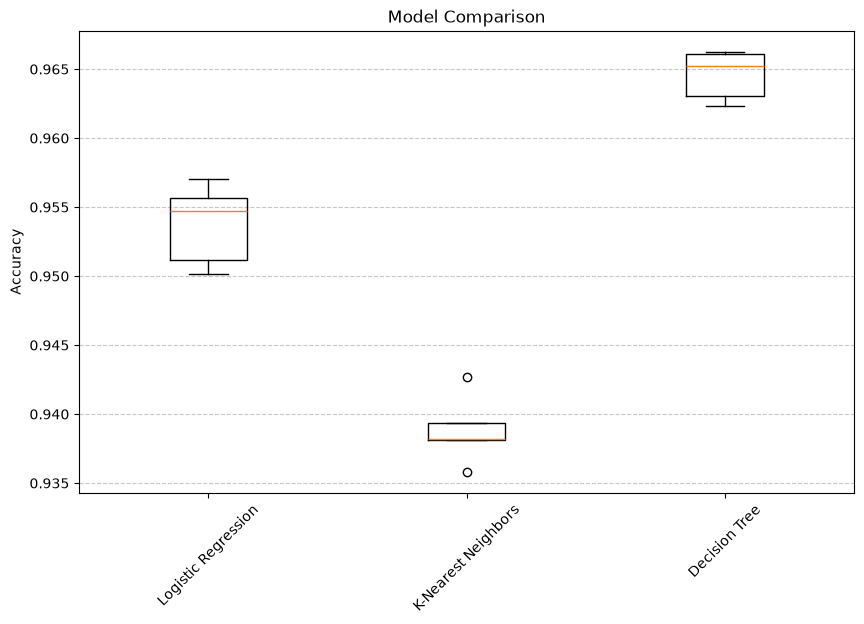

In [19]:
results = {}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, pipeline in pipelines.items():
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=skf, scoring='accuracy')
    results[name] = cv_scores
    print(f"{name}: Mean Accuracy = {cv_scores.mean():.4f}, Std = {cv_scores.std():.4f}")
    
# Plot the results
plt.figure(figsize=(10, 6))
plt.boxplot(results.values(), label=results.keys())
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.xticks(range(1, len(results) + 1), results.keys())
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
    

In [20]:
# Winner model parameters:
print(DecisionTreeClassifier().get_params())

{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': None, 'splitter': 'best'}


In [21]:
# We see that Decision Tree outperforms the other models in terms of accuracy. 
# Hyperparameter tuning can be performed on the Decision Tree model to further improve its performance
from sklearn.model_selection import GridSearchCV

dt_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("dt", DecisionTreeClassifier(random_state=42))
])

param_grid = {
    "dt__max_depth": [None, 5, 10, 15],
    "dt__min_samples_split": [2, 5, 10, 20],
    "dt__min_samples_leaf": [1, 2, 4],
    "dt__criterion": ["gini", "entropy"]
}

# Create GridSearchCV object
grid_search = GridSearchCV(dt_pipeline, param_grid, cv=skf, scoring='accuracy', n_jobs=-1)

print("Performing grid search...")
grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

Performing grid search...
Best parameters: {'dt__criterion': 'entropy', 'dt__max_depth': 10, 'dt__min_samples_leaf': 4, 'dt__min_samples_split': 20}
Best cross-validation accuracy: 0.9745


### Using tuned model


In [22]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

              precision    recall  f1-score   support

      GALAXY       0.98      0.99      0.98     11889
         QSO       0.96      0.92      0.94      3792
        STAR       1.00      1.00      1.00      4319

    accuracy                           0.98     20000
   macro avg       0.98      0.97      0.97     20000
weighted avg       0.98      0.98      0.98     20000



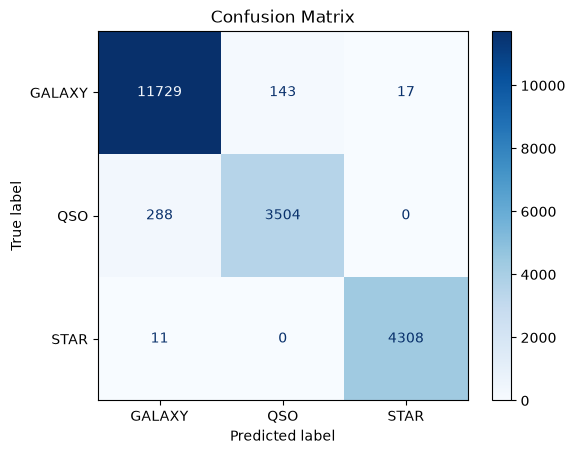

In [23]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# Print classification report
print(classification_report(y_test, y_pred))

# Display confusion matrix
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test, display_labels=best_model.classes_, cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

### 📊 Model Evaluation & Key Insights

**Overall Performance**
The tuned Decision Tree classifier achieved an exceptional overall accuracy of **98%** on the unseen test dataset. The pruning strategies applied during hyperparameter tuning successfully prevented overfitting, yielding a highly robust and scientifically consistent classification model.

**Class-Level Breakdown**
* ⭐ **Stars (STAR):** The model demonstrated perfect precision and recall (`F1-score: 1.00`), flawlessly isolating stars from other celestial bodies.
* 🌌 **Galaxies (GALAXY):** Classification was highly accurate (`F1-score: 0.98`), with minimal misclassifications.
* 🔭 **Quasars (QSO):** This was the model's primary challenge (`Recall: 0.92`). Specifically, 288 Quasars were misclassified as Galaxies.

> **💡 Astrophysical Context:** 
> *This margin of error is expected. Quasars are highly luminous active galactic nuclei with optical and spectral features that closely overlap with standard galaxies, making them difficult to distinguish even for astronomers without deep spectroscopic analysis.*